In [1]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sympy import symbols, simplify, sin, expand, sympify, lambdify
from sklearn.model_selection import train_test_split
from scipy.special import jn,j0, factorial

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/numpy/_core/getlimits.py:552: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
import pymc as pm
import arviz as az

In [3]:
x = np.linspace(-2, 2, 700)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
noise = rng.normal(size=x.shape, scale = 0.05)
y = np.cos(x) + noise 
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)

In [4]:
default_pysr_params = dict(
    populations=30,
    model_selection="best",
)

In [5]:
model = PySRRegressor(
    niterations=500,
    populations=50,
    binary_operators=["+", "*", "/", "-"],
    unary_operators=["square", "cos", "sin", "sqrt"],
    maxdepth = 2,
    #maxsize = 100
)
model.fit(x_train.reshape(-1, 1), y_train)

/home/paolo/.conda/envs/pymc_env/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 3.300e+05
Progress: 3594 / 25000 total iterations (14.376%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.009e-01  0.000e+00  y = 0.46335
2           2.431e-03  4.415e+00  y = cos(x₀)
4           2.428e-03  7.271e-04  y = cos(x₀) - 0.001881
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 3.260e+05
Progress: 7756 / 25000 total iterations (31.024%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['square', 'cos', ...]"
,expression_spec,None
,niterations,500
,populations,50
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,2
,warmup_maxsize_by,None


  - outputs/20251209_101746_Mts68M/hall_of_fame.csv


In [6]:
model.sympy

<bound method PySRRegressor.sympy of PySRRegressor.equations_ = [
	   pick     score                equation      loss  complexity
	0        0.000000              0.46335277  0.200948           1
	1  >>>>  4.414619                 cos(x0)  0.002431           2
	2        0.000727  cos(x0) - 0.0018804355  0.002428           4
]>

In [7]:
model.sympy()

cos(x0)

In [8]:
formulas = [simplify(model.equations_['equation'][i]) for i in model.equations_['equation'].index]
formulas

[0.463352770000000, cos(x0), cos(x0) - 0.0018804355]

In [9]:
x_simb = symbols('x0')
symbol_map = {'x0': x_simb}

# Converts the equtions (stored into the 'Feature Expression' column of df) from strings into sympy objects
sympy_exprs = [sympify(f, locals=symbol_map) for f in formulas]
sympy_exprs

[0.463352770000000, cos(x0), cos(x0) - 0.0018804355]

In [26]:
from sympy import symbols, cos

x0 = symbols('x0')

c0_list = []
a0_f = []
for expr in sympy_exprs:
    c0_val, rest = expr.as_independent(x0)
    c0_list.append(c0_val) 
    a0_f.append(rest)

c0_list, a0_f

([0.463352770000000, 1, -0.00188043550000000], [1, cos(x0), cos(x0)])

In [28]:
c0 = np.array(c0_list, dtype=float)

In [29]:
def eval_function(f, x):
    ' Constant function'
    if f.has(x0) == 0:
        return np.tile(f, (x.size, 1))
    else:
        func = lambdify(x0, f, 'numpy')
        return func(x)

In [30]:
# In each column are stacked data for each of the 4 different formulas
Phi = np.column_stack([eval_function(f, x_train) for f in a0_f]).astype(float)
Phi_test = np.column_stack([eval_function(f, x_test) for f in a0_f]).astype(float)
Phi_tot = np.column_stack([eval_function(f, x) for f in a0_f]).astype(float)

In [31]:
Phi

array([[1.        , 0.34737792, 0.34737792],
       [1.        , 0.71012832, 0.71012832],
       [1.        , 0.2986438 , 0.2986438 ],
       ...,
       [1.        , 0.89828932, 0.89828932],
       [1.        , 0.882676  , 0.882676  ],
       [1.        , 0.15387354, 0.15387354]], shape=(469, 3))

In [15]:
traces = []
models_stored = len(a0_f)
for i in range(models_stored):
    with pm.Model() as model:
        # Select the i-th model
        f = Phi[:, i]

        # Priors, Che valori di sigma potrei usare? 10 forse è un po' troppo
        c0_coeff = pm.Normal("c0", mu=c0[i], sigma=10)
        a0_coeff = pm.Normal("a0", mu=1, sigma=10)
        sigma = pm.HalfNormal("sigma", sigma=2)

        # Linear parametrization
        mu = c0_coeff + a0_coeff * f

        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train)

        # Sample from posterior
        # Sequential montecarlo chiedi spiegazione
        trace = pm.smc.sample_smc()
        #trace = pm.sample()
        traces.append(trace)

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

Initializing SMC sampler...
Sampling 6 chains in 6 jobs


Output()

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


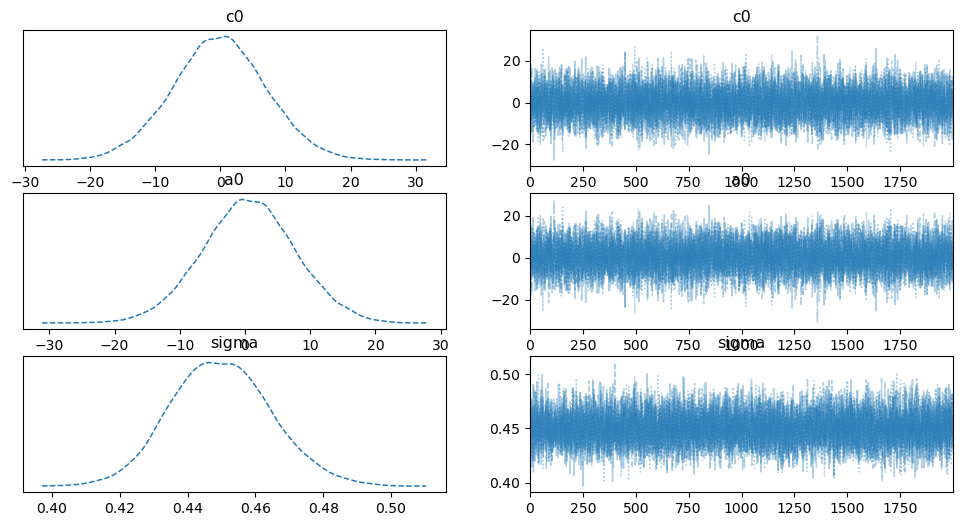

In [16]:
az.plot_trace(traces[0], combined=True);